# Trabajo práctico N.º 1 - Finanzas Computacionales.
Andrés Polakoff, Baltazar Rojas Yenni, Simón Jaimovich y Uriel Corral Bianco.

In [ ]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
%matplotlib inline

Primero creamos una función auxiliar para poder hacer los gráficos posteriormente.

In [ ]:
def grid_weights_sum1(low=-1.5, high=1.5, step=0.05):
    # Índices enteros para el grid: w = i*step
    ilow  = int(np.ceil(low/step))
    ihigh = int(np.floor(high/step))
    S = int(round(1.0/step))  # i + j + k = S  <=>  (i*step + j*step + k*step = 1)

    lst = []
    for i in range(ilow, ihigh+1):
        for j in range(ilow, ihigh+1):
            k = S - i - j
            lst.append([i*step, j*step, k*step])

    return np.array(lst)

**Punto 1: Implementación base.**

El ratio de Sharpe se define como

$$
S(w) \;=\; \frac{w^\top \mu - r_f}{\sqrt{w^\top \Sigma w}}
$$

En la siguiente función lo computamos realizando las operaciones matriciales con la ayuda de NumPy.

In [ ]:
def sharpe(weights, returns, cov_matrix, rf):
    e_returns = returns.mean().to_numpy() # Agarramos los retornos y sacamos promedios para obtener retornos esperados
    portfolio_returns = e_returns @ weights # Multiplicamos por el vector weights para obtener el retorno esperado del portafolio
    portfolio_variance = weights.T @ cov_matrix @ weights # Hacemos la multiplicación doble para obtener la varianza de la cartera
    sharpe = (portfolio_returns - rf) / np.sqrt(portfolio_variance) # Computamos el ratio de sharpe con la fórmula

    return sharpe

En este método calculamos el gradiente del ratio de sharpe para unos weights del portafolio.
Para cada peso $w_i$ armamos dos versiones del portafolio, una con $w_i + h$ (adelantado) y otra con $w_i - h$ (atrasado).  

Después calculamos el Sharpe en esos dos casos y usamos la fórmula de derivada centrada:

$$
\frac{\partial S}{\partial w_i} \approx \frac{S(w_i + h) - S(w_i - h)}{2h}
$$

Juntamos las derivadas parciales y conseguimos el vector gradiente.  
Ese gradiente después lo usamos en `g_descent` para ajustar los weights e ir optimizanado el Sharpe.


In [ ]:
def gradiente(weights, returns, cov_matrix, rf, h=1e-05):
    w = np.asarray(weights, dtype=float)
    grad = np.zeros_like(weights)
    for i in range(len(weights)):
        w_forward = w.copy()
        w_backward = w.copy()
        w_forward[i] = w_forward[i] + h
        w_backward[i] -= h
        f_plus = sharpe(w_forward, returns, cov_matrix, rf)*np.sqrt(252)
        f_minus = sharpe(w_backward, returns, cov_matrix, rf)*np.sqrt(252)
        grad[i] = (f_plus - f_minus) / (2*h)
    return grad

**Puntos 2, 3 y 4: Descenso por gradiente simple, long only y análisis gráfico.**

Partiendo de unos weights predeterminados, creamos un loop que, via un pequeño step, vaya llevando los weights hacia el óptimo. Para esto utilizamos el gradiente del ratio de sharpe en cada iteración. Creamos una condición en la función para poder decidir si permitimos shortear activos o, como solicita el punto 3, ir long only.

En el gráfico podemos ver el trayecto de los sharpes hasta el óptimo, vemos como los weights van viajando por la restricción de suma 1 hasta llegar al punto máximo de la función del ratio de sharpe.


In [ ]:
def g_descent(weights, returns, cov_matrix, rf, tickers, short=True, max_iter=20000, lr=0.01):
    hist = [weights.copy()]
    hist_sharpe = [sharpe(weights, returns, cov_matrix, rf)*np.sqrt(252)]
    # con estas 2 listas guardamos los puntos por donde pasa el descent para poder graficar los sharpes posteriormente
    for k in range(max_iter):
        grad = gradiente(weights, returns, cov_matrix, rf) # computamos el gradiente en cada iteración

        t = 1
        for i in range(len(weights)):
            if short == True:
                weights[i] = weights[i] + grad[i] * lr # nos movemos con el step hacia el gradiente
            else:
                weights[i] = max(weights[i] + grad[i] * lr , 0) # para la condición de long only, hacemos que si un weight quiere ser < 0, se resetee
                                                                # a 0, lo que evita el shorteo


        weights = weights / np.sum(weights)
        hist.append(weights)
        hist_sharpe.append(sharpe(weights,returns, cov_matrix, rf)*np.sqrt(252)) # computamos en sharpe para los weights en cada step
        if k > 105:
            if hist_sharpe[-1] - hist_sharpe[-100] < 1e-04: # condición de finalización del loop
                print("Nro iteraciones:", k)
                break
    hist = np.array(hist)

    malla = grid_weights_sum1(low=-2, high=2, step=0.05)
    curva_sharpes = []
    for w in malla:
        curva_sharpes.append((sharpe(w, returns, cov_matrix, rf))*np.sqrt(252))
    np.array(curva_sharpes)

    fig = plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111, projection="3d")
    triang = mtri.Triangulation(malla[:,0], malla[:,1])
    surf = ax.plot_trisurf(triang, curva_sharpes, cmap='viridis', linewidth=0.0, antialiased=True, edgecolor=None)

    ax.plot(hist[:,0], hist[:,1], hist_sharpe, color='red', lw=1,marker='s')
    ax.view_init(elev=20, azim=80)


    ax.set_xlabel("w1")
    ax.set_ylabel("w2")
    ax.set_zlabel("Sharpe")
    fig.colorbar(surf, ax=ax, shrink=0.65, pad=0.05, label='Valor sharpe')
    ax.set_title("Malla de combinaciones de weights")

    plt.show()

    print("Weights:", weights)
    print("Suma weights:", np.sum(weights))
    print("Sharpe:", sharpe(weights, returns, cov_matrix, rf)*np.sqrt(252))

    return weights, hist, hist_sharpe


**Input de prueba.**

C:\Users\polak\AppData\Local\Temp\ipykernel_24156\503440156.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, period = "5y",interval =
[*********************100%***********************]  3 of 3 completed


Nro iteraciones: 1244


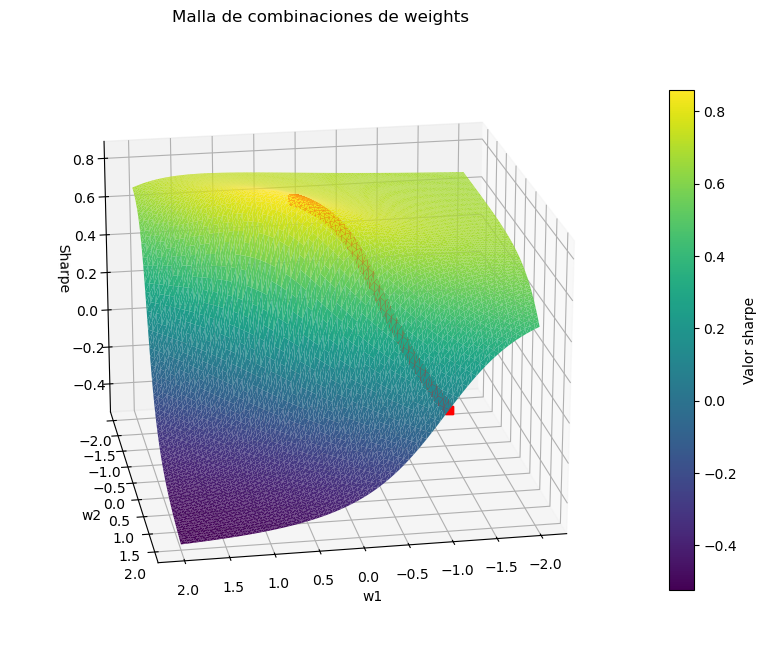

Weights: [0.41415037 0.02547944 0.56037019]
Suma weights: 1.0
Sharpe: 0.8507788560771633


In [ ]:
tickers = ["aapl", "amzn", "ypf",]
prices = yf.download(tickers, period = "5y",interval =
"1d" )["Close"]
returns = prices.pct_change()[1:]
cov_matrix = returns.cov().to_numpy()
rf_anual = 0.04
rf = (1 + rf_anual)**(1/252) - 1
weights = np.array([-1,2,0])

a=g_descent(weights, returns, cov_matrix, rf, tickers, short=True)